## Agromanager Miscanthus Giganteus 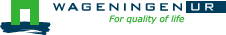


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
import yaml
import os 

In [8]:
# Create output directory
out_dir = Path("/Users/paulianoprescu/Projects/wofost_miscanthus/giganteus/calibration/agromanager")

# Define Agromanagement Assumptions
#
# Since Miscanthus is a perennial, each growing season is modelled as a different campaign 

crop_name = "miscanthus_giganteus"
variety_name = "miscanthus_giganteus"
crop_start_type = "emergence"   # rhizome sprouting = emergence; have not chosen for sowing
crop_end_type = "harvest"  

# Growing Season Window (month, day)
start_month, start_day = 1, 1   # In January, the Aliartos measurements were taken, including biomass yield, thus implying harvest
end_month, end_day = 12, 30    # At this point in time I assume the crop to be fully grown

# Years to simulate 
years = list(range(2013, 2026))

# Year 1: campaign starts 90 days early for spin-up
first_year = years[0]
first_campaign = f"""- {first_year - 1}-10-01:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {variety_name}
        crop_start_date: {first_year}-{start_month:02d}-{start_day:02d}
        crop_start_type: {crop_start_type}
        crop_end_date: {first_year}-{end_month:02d}-{end_day:02d}
        crop_end_type: {crop_end_type}
        max_duration: null
    TimedEvents: null
    StateEvents: null"""

# Subsequent years: campaign starts on crop_start_date (no extra spin-up)
later_campaigns = "\n".join([f"""- {year}-{start_month:02d}-{start_day:02d}:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {variety_name}
        crop_start_date: {year}-{start_month:02d}-{start_day:02d}
        crop_start_type: {crop_start_type}
        crop_end_date: {year}-{end_month:02d}-{end_day:02d}
        crop_end_type: {crop_end_type}
        max_duration: null
    TimedEvents: null
    StateEvents: null""" for year in years[1:]])

campaigns = first_campaign + "\n" + later_campaigns

miscanthus_agro = f"""Version: 1.0.0
AgroManagement:
{campaigns}
- {years[-1]}-12-31:
    CropCalendar: null
    TimedEvents: null
    StateEvents: null
"""

os.makedirs(out_dir, exist_ok=True)
outpath = out_dir / f"miscgig_agro.yaml"
with open(outpath, 'w') as f:
    f.write(miscanthus_agro)
print(f"Miscanthus AgroManagement CropCalender file written to: {outpath}")

Miscanthus AgroManagement CropCalender file written to: /Users/paulianoprescu/Projects/wofost_miscanthus/giganteus/calibration/agromanager/miscgig_agro.yaml
